In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wine-ensgti-2026/sample_submission.csv
/kaggle/input/wine-ensgti-2026/train.csv
/kaggle/input/wine-ensgti-2026/test.csv


# 1. Imports And Style Configuration

In [12]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

# Metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

# Settings
import warnings
warnings.filterwarnings('ignore')

# --- Dark theme palatte
PALETTE  = ['#C0392B', '#2980B9','#27AE60','#8E44AD','#E67E22','#1ABC9C']
BG_COLOR = '#0F1117'
PANEL_COLOR = '#1A1D27'
TEXT_COLOR = '#E8E8E8'
GRID_COLOR = '#2A2D3A'
ACCENT_COLOR = '#C0392B'

plt.rcParams.update({
    'figure.facecolor':  BG_COLOR,
    'axes.facecolor':    PANEL_COLOR,
    'axes.edgecolor':    GRID_COLOR,
    'axes.labelcolor':   TEXT_COLOR,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'text.color':        TEXT_COLOR,
    'grid.color':        GRID_COLOR,
    'grid.linewidth':    0.5,
    'grid.alpha':        0.4,
    'legend.facecolor':  PANEL_COLOR,
    'legend.edgecolor':  GRID_COLOR,
    'axes.spines.top':   False,
    'axes.spines.right': False,

})
print('Import Done Succesfully')

Import Done Succesfully


# 2. Load And Explore Data

In [13]:
# Load Training Data
train = pd.read_csv('/kaggle/input/wine-ensgti-2026/train.csv')

# Load Testing Data
test = pd.read_csv('/kaggle/input/wine-ensgti-2026/test.csv')

# Explore training data
print(f'training data shape {train.shape}')
print("\nFirst few row")
train.head()

training data shape (3898, 13)

First few row


,id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,5.986500,0.281967,0.419604,10.832288,0.046696,55.477764,150.590385,0.993946,3.092111,0.590847,10.920676,3
1,1,5.421364,0.527669,0.171727,2.833312,0.034760,34.808504,126.733891,0.988669,3.196534,0.527903,13.261434,8
2,2,7.079385,0.239195,0.396151,1.741136,0.035217,31.588860,127.237085,0.990705,3.293212,0.417838,12.217271,8
3,3,7.324859,0.293670,0.348868,1.598075,0.054197,32.279923,148.281022,0.991828,3.181351,0.468004,10.648563,5
4,4,6.480897,0.322427,0.347538,5.607307,0.043802,27.508774,93.000700,0.991914,3.283934,0.604405,11.983263,7


In [14]:
# Dataset Information
print("\nColumn info")
print(train.info())



Column info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3898 non-null   int64  
 1   fixed acidity         3898 non-null   float64
 2   volatile acidity      3898 non-null   float64
 3   citric acid           3898 non-null   float64
 4   residual sugar        3898 non-null   float64
 5   chlorides             3898 non-null   float64
 6   free sulfur dioxide   3898 non-null   float64
 7   total sulfur dioxide  3898 non-null   float64
 8   density               3898 non-null   float64
 9   pH                    3898 non-null   float64
 10  sulphates             3898 non-null   float64
 11  alcohol               3898 non-null   float64
 12  quality               3898 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 396.0 KB
None


In [15]:
# Check missing values
print("\nMissing Values")
print(train.isnull().sum())


Missing Values
id                      0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


# 3. Exploratiory Data Analysis

In [16]:
# Split dataset
X_raw=train.drop(['id','quality'],axis=1)

In [17]:
# Descriptive Statistic
print("Descriptive Statistic")
train.describe()

Descriptive Statistic


,id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000,3898.000000
mean,1948.500000,6.852953,0.277884,0.334951,6.376394,0.045669,35.248562,138.008984,0.994016,3.187975,0.491241,10.520216,5.888404
std,1125.400003,0.854943,0.101430,0.121982,5.099640,0.021832,17.007702,42.355389,0.003008,0.151720,0.115648,1.232149,0.942599
min,0.000000,3.781734,0.075851,-0.012257,0.262584,0.009937,0.958903,11.834655,0.986880,2.760199,0.229256,8.104604,3.000000
25%,974.250000,6.287593,0.209409,0.266276,1.762750,0.035505,23.305632,108.382734,0.991703,3.084402,0.408197,9.469486,5.000000
50%,1948.500000,6.791694,0.262075,0.315894,5.177034,0.042721,33.636319,133.594780,0.993729,3.174738,0.475596,10.369315,6.000000
75%,2922.750000,7.339199,0.323466,0.388020,9.922097,0.049958,45.641489,166.633498,0.996126,3.280627,0.551209,11.385841,6.000000
max,3897.000000,14.169637,1.004999,1.661049,65.896617,0.348356,289.384197,436.609261,1.039154,3.806469,1.085471,14.196928,9.000000


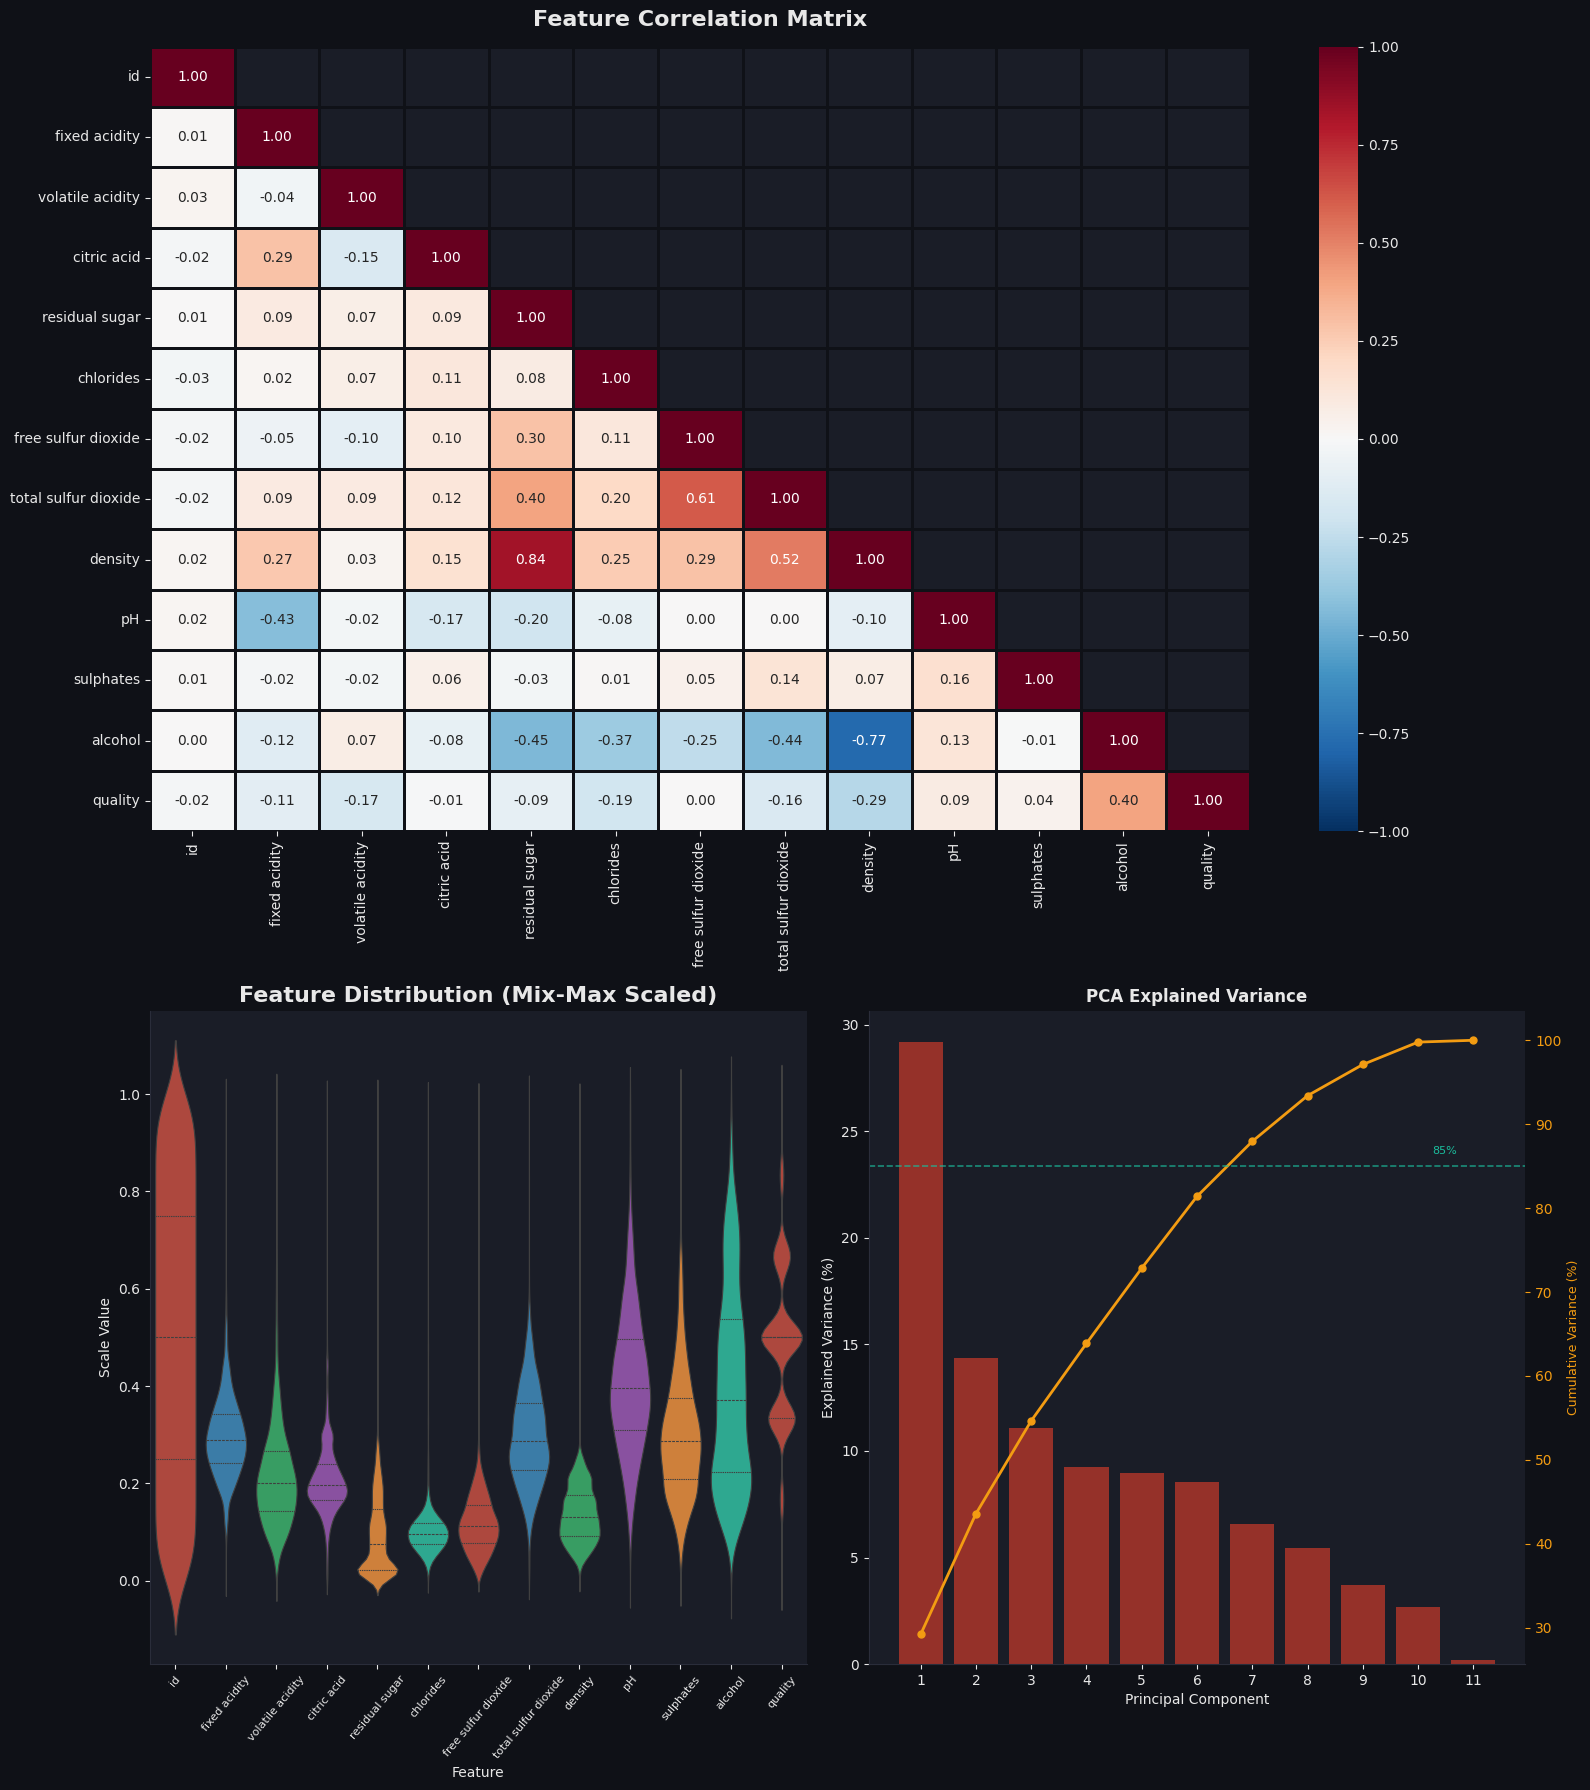

In [20]:
# Visualization
fig = plt.figure(figsize=(16, 18), facecolor=BG_COLOR)
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.2, 1]) 

ax1 = fig.add_subplot(gs[0, :]) 
corr = train.corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask_upper, ax=ax1, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=1, linecolor=BG_COLOR,
            annot=True, fmt='.2f', annot_kws={'size': 10})
ax1.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', color=TEXT_COLOR, pad=15)

# Violin Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_norm = train.copy()
for col in train_norm.columns:
    mn,mx= train_norm[col].min(),train_norm[col].max()
    if mx > mn:
        train_norm[col] = (train_norm[col]-mn) / (mx-mn)
        
train_melt= train_norm.melt(var_name='Feature',value_name='Scale Value')
sns.violinplot(data=train_melt,x='Feature',y='Scale Value',
              palette=PALETTE[:len(train.columns)],
              ax=ax2,inner='quartile',linewidth=0.8)
ax2.set_title('Feature Distribution (Mix-Max Scaled)',fontsize=16, fontweight='bold', color=TEXT_COLOR)
ax2.tick_params(axis='x',rotation=50,labelsize=8)

# PCA explained Variance
ax3 = fig.add_subplot(gs[1, 1])
pca_full= Pipeline([('s',StandardScaler()),('p',PCA(random_state=42))])
pca_full.fit(X_raw)
ev= pca_full.named_steps['p'].explained_variance_ratio_
cumev = np.cumsum(ev)
comps= range(1,len(ev)+1)
ax3.bar(comps,ev*100,color=ACCENT_COLOR,alpha=0.75,zorder=3)
ax_3=ax3.twinx()
ax_3.plot(comps, cumev*100, 'o-', color='#F39C12', lw=2, ms=5)
ax_3.axhline(85, color='#1ABC9C', ls='--', lw=1.2, alpha=0.7)
ax_3.text(len(ev)-0.3, 86.5, '85%', color='#1ABC9C', fontsize=8, ha='right')
ax_3.set_ylabel('Cumulative Variance (%)', color='#F39C12', fontsize=9)
ax_3.tick_params(colors='#F39C12')
ax_3.set_facecolor(PANEL_COLOR)
ax3.set_xlabel('Principal Component'); ax3.set_ylabel('Explained Variance (%)')
ax3.set_title('PCA Explained Variance', fontsize=12, fontweight='bold')
ax3.set_xticks(list(comps))

plt.tight_layout()
plt.show()

# 4. Pipeline

In [28]:
# kmean with standard scaler inside pipeline
def build_kmeans_pipeline(n_clusters=3) -> Pipeline:
    return Pipeline([
        ('scaler',StandardScaler()),
        ('kmeans',KMeans(n_clusters=n_clusters,random_state=42,n_init=20)),
    ])

# dbscan with standard scaler inside pipeline
def build_dbscan_pipeline(eps=0.8,min_samples=10) -> Pipeline:
    return Pipeline([
        ('scaler',StandardScaler()),
        ('dbscan',DBSCAN(eps=eps,min_samples=min_samples)),
    ])

#  hdbscan with standard scaler inside pipeline
def build_hdbscan_pipeline(min_cluster_size=20) -> Pipeline:
    return Pipeline([
        ('scaler',StandardScaler()),
        ('hdbscan',HDBSCAN(min_cluster_size=min_cluster_size,store_centers='centroid')),
     ])

# pca with standard scaler inside pipeline
def build_pca_pipeline(n_components=2) -> Pipeline:
    return Pipeline([
        ('scaler',StandardScaler()),
        ('pca',PCA(n_components=n_components,random_state=42)),
    ])

print('Pipeline Defined')
print('  -> build_kmeans_pipeline(n_clusters)')
print('  -> build_dbscan_pipeline(eps, min_samples)')
print('  -> build_hdbscan_pipeline(min_cluster_size)')
print('  -> build_pca_pipeline(n_components)')


Pipeline Defined
  -> build_kmeans_pipeline(n_clusters)
  -> build_dbscan_pipeline(eps, min_samples)
  -> build_hdbscan_pipeline(min_cluster_size)
  -> build_pca_pipeline(n_components)


# 5. KMeans- Elbow Method & Silhouette Analysis

Best k by silhouette: 2 (score=0.2138)


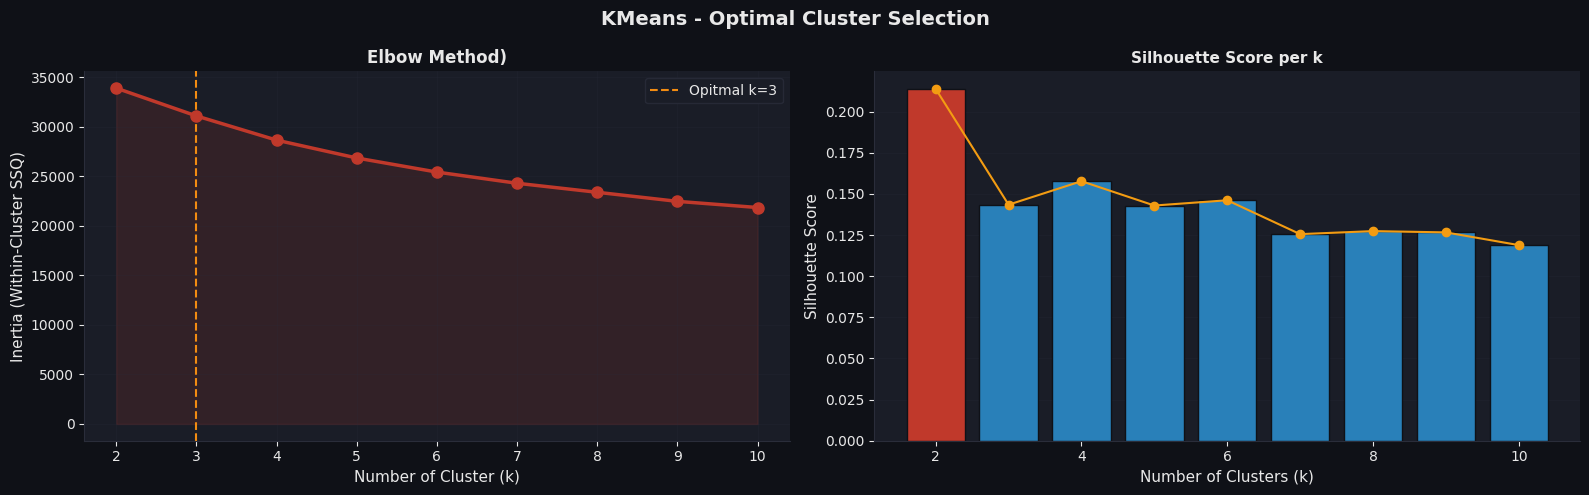

In [29]:
k_range = range(2,11)
inertias,silhouettes=[],[]

for k in k_range:
    pipe=build_kmeans_pipeline(k)
    pipe.fit(X_raw)
    labels = pipe.named_steps['kmeans'].labels_
    X_scaled = pipe.named_steps['scaler'].transform(X_raw)
    inertias.append(pipe.named_steps['kmeans'].inertia_)
    silhouettes.append(silhouette_score(X_scaled,labels))

k_vals=list(k_range)
best_k= k_vals[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k} (score={max(silhouettes):.4f})')

fig,axes = plt.subplots(1,2,figsize=(16,5),facecolor=BG_COLOR)
fig.suptitle('KMeans - Optimal Cluster Selection',fontsize=14,fontweight='bold',color=TEXT_COLOR)

# Elbow
axes[0].plot(k_vals,inertias,'o-',color=ACCENT_COLOR,lw=2.5,ms=8,zorder=3)
axes[0].fill_between(k_vals,inertias,alpha=0.15,color=ACCENT_COLOR)
axes[0].axvline(3,ls='--',color='#F38C12',lw=1.5,label='Opitmal k=3')
axes[0].set_xlabel('Number of Cluster (k)',fontsize=11)
axes[0].set_ylabel('Inertia (Within-Cluster SSQ)',fontsize=11)
axes[0].set_title('Elbow Method)',fontsize=12,fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)


# Silhouette 
colors_s=[ACCENT_COLOR if s == max(silhouettes) else '#2980B9' for s in silhouettes]
axes[1].bar(k_vals,silhouettes, color=colors_s,zorder=3,edgecolor=BG_COLOR)
axes[1].plot(k_vals,silhouettes,'o-',color='#F39C12',lw=1.5,ms=6,zorder=4)
axes[1].set_xlabel('Number of Clusters (k)',fontsize=11)
axes[1].set_ylabel('Silhouette Score',fontsize=11)
axes[1].set_title('Silhouette Score per k',fontsize=11,fontweight='bold')
axes[1].grid(axis='y',alpha=0.3)

plt.tight_layout(); plt.show()



# 6. Fit All Clustering Models

In [30]:
# KMeans
km_pipe = build_kmeans_pipeline(n_clusters=3)
km_pipe.fit(X_raw)
kmeans_labels = km_pipe.named_steps['kmeans'].labels_
print(f"KMeans -> Clusters: {len(set(kmeans_labels))} Distribution: {dict(zip(*np.unique(kmeans_labels,return_counts=True)))}")


# DBSCAN
db_pipe= build_dbscan_pipeline(eps=2.5,min_samples=8)
db_pipe.fit(X_raw)
dbscan_labels= db_pipe.named_steps['dbscan'].labels_
n_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN -> Clusters: {n_db} Noise: {(dbscan_labels==-1).sum()}")

# HDBSCAN

hdb_pipe = build_hdbscan_pipeline(min_cluster_size=20)
hdb_pipe.fit(X_raw)
hdbscan_labels = hdb_pipe.named_steps['hdbscan'].labels_
n_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
print(f"HDBSCAN -> Clusters: {n_hdb} Noise: {(hdbscan_labels==-1).sum()}")


KMeans -> Clusters: 3 Distribution: {np.int32(0): np.int64(1156), np.int32(1): np.int64(1392), np.int32(2): np.int64(1350)}
DBSCAN -> Clusters: 1 Noise: 80
HDBSCAN -> Clusters: 3 Noise: 3612


# 7. Dimensionality Reduction (PCA + t-SNE)

In [32]:
# PCA 2D
pca_pipe = build_pca_pipeline(n_components=2)
pca_2d = pca_pipe.fit_transform(X_raw)
print(f"PCA 2D shape: {pca_2d.shape}")

# t-SNE 2D 
X_scaled_tsne = StandardScaler().fit_transform(X_raw)
tsne = TSNE(n_components=2,perplexity=40,random_state=42,max_iter=1000)
tsne_2d = tsne.fit_transform(X_scaled_tsne)
print(f't-SNE 2D shape: {tsne_2d.shape}')

PCA 2D shape: (3898, 2)
t-SNE 2D shape: (3898, 2)


# 8. PCA Scatter - Cluster Comparison

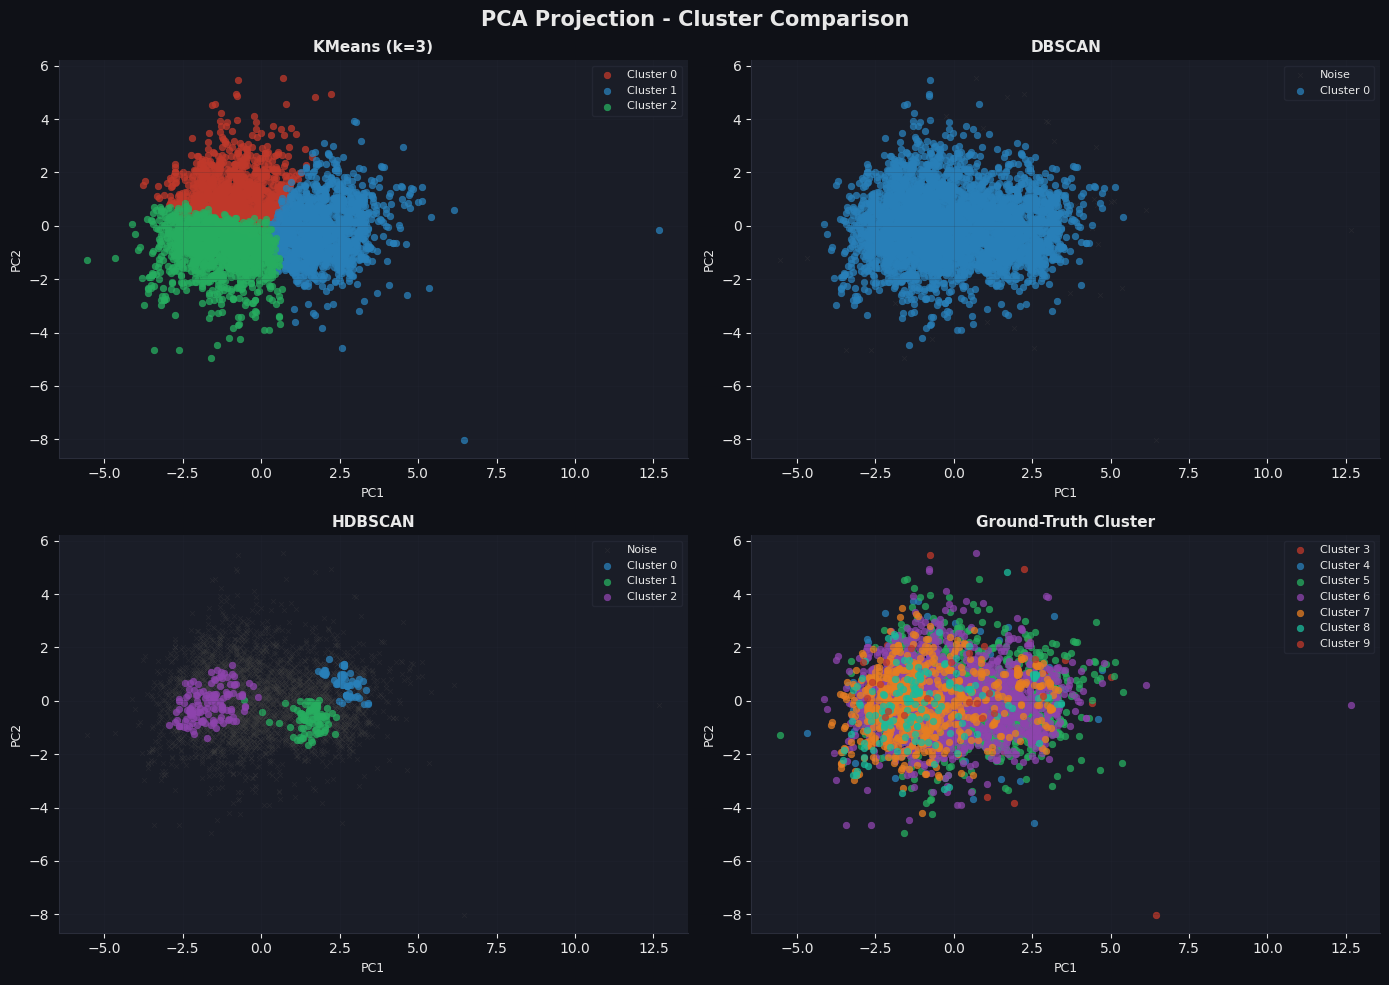

In [41]:
fig, axes = plt.subplots(2,2,figsize=(14,10), facecolor=BG_COLOR)
fig.suptitle('PCA Projection - Cluster Comparison',fontsize=15,
            fontweight='bold',color=TEXT_COLOR)
configs= [
    ('KMeans (k=3)',   kmeans_labels),
    ('DBSCAN',         dbscan_labels),
    ('HDBSCAN',        hdbscan_labels),
    ('Ground-Truth Cluster', train['quality'].values ),
]

for ax, (title,labels) in zip(axes.flatten(),configs):
    unique_labels = sorted(set(labels))
    for i , lbl in enumerate(unique_labels):
        mask = labels == lbl
        clr = '#444444' if lbl == -1 else PALETTE[i % len(PALETTE)]
        alpha = 0.30 if lbl == -1 else 0.75
        size = 12 if lbl == -1 else 22
        mkr = 'x' if lbl == -1 else 'o'
        lstr = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(pca_2d[mask,0],pca_2d[mask,1], c=clr,s=size,
                  alpha=alpha, marker=mkr,label=lstr,linewidths=0.5)
    ax.set_title(title,fontsize=11,fontweight='bold')
    ax.set_xlabel('PC1',fontsize=9); ax.set_ylabel('PC2',fontsize=9)
    ax.legend(fontsize=8,framealpha=0.6); ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

# 9. t-SNE Scatter - Non-Linear Projection

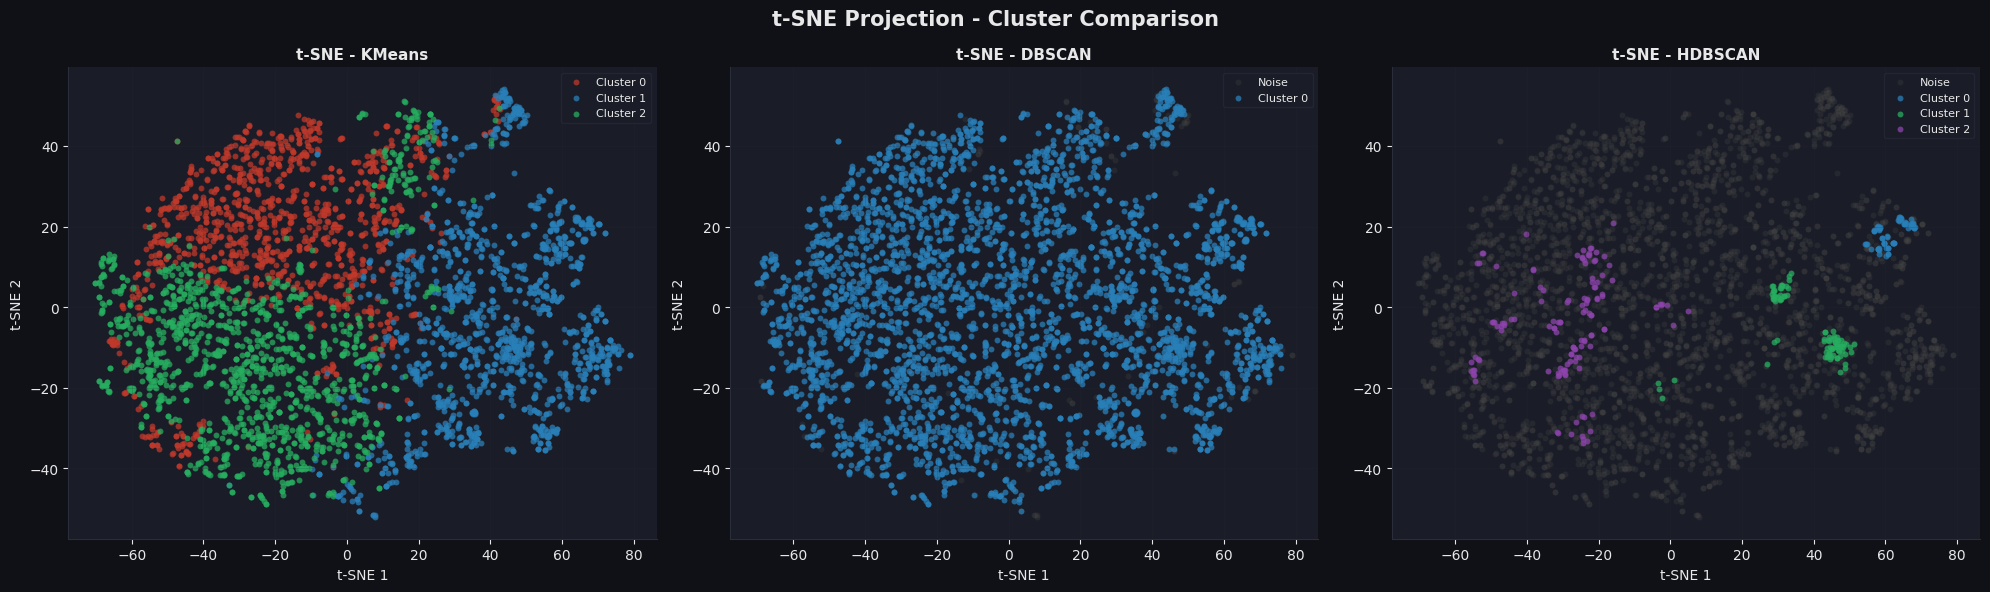

In [45]:
fig, axes= plt.subplots(1,3, figsize=(20,6),facecolor=BG_COLOR)
fig.suptitle('t-SNE Projection - Cluster Comparison',fontsize=15,
            fontweight='bold',color=TEXT_COLOR)

for ax, (title,labels) in zip(axes,[
    ('KMeans', kmeans_labels),
    ('DBSCAN', dbscan_labels),
    ('HDBSCAN',hdbscan_labels),
]):
    for i , lbl in enumerate(sorted(set(labels))):
        mask = labels== lbl
        clr = '#444444' if lbl == -1 else PALETTE[i % len(PALETTE)]
        lstr = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(tsne_2d[mask,0],tsne_2d[mask,1],c=clr,s=18,
                  alpha=0.3   if lbl == -1 else 0.75, label=lstr,linewidths=0)
    ax.set_title(f't-SNE - {title}', fontsize=11,fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8 , framealpha=0.6); ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()